In [29]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [30]:
df = pd.read_csv('gemini.csv')

In [31]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)


In [32]:
model = CatBoostClassifier(
    iterations=500,           # для маленьких данных лучше меньше итераций + раннее стоппинг
    learning_rate=0.03,
    depth=6,
    auto_class_weights='Balanced', # Решает проблему дисбаланса 0 и 1
    eval_metric='F1',          # Оптимизируем под дисбаланс, а не под точность
    verbose=100,               # Выводить лог каждые 100 шагов
    random_seed=42
)

# 3. Обучение с защитой от переобучения
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50   # Остановится, если F1 перестанет расти
)

# 4. Получение вероятностей
y_proba = model.predict_proba(X_test)[:, 1]

# 5. Предсказание классов
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

0:	learn: 0.9696970	test: 0.6315789	best: 0.6315789 (0)	total: 1.24ms	remaining: 617ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9166666667
bestIteration = 3

Shrink model to first 4 iterations.
              precision    recall  f1-score   support

         0.0       0.85      1.00      0.92        11
         1.0       1.00      0.85      0.92        13

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24



In [33]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 91.67%


Accuracy:0.917
Precision:1.000
Recall:  0.846
F1-score: 0.917

Confusion Matrix:
 [[11  0]
 [ 2 11]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      1.00      0.92        11
         1.0       1.00      0.85      0.92        13

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24

0:	learn: 0.9411765	total: 800us	remaining: 399ms
100:	learn: 1.0000000	total: 66.2ms	remaining: 262ms
200:	learn: 1.0000000	total: 131ms	remaining: 195ms
300:	learn: 1.0000000	total: 198ms	remaining: 131ms
400:	learn: 1.0000000	total: 266ms	remaining: 65.8ms
499:	learn: 1.0000000	total: 332ms	remaining: 0us
0:	learn: 1.0000000	total: 1.05ms	remaining: 524ms
100:	learn: 1.0000000	total: 65.7ms	remaining: 259ms
200:	learn: 1.0000000	total: 127ms	remaining: 189ms
300:	learn: 1.0000000	total: 185ms	remaining: 122ms
400:	learn: 1.0000000	total: 

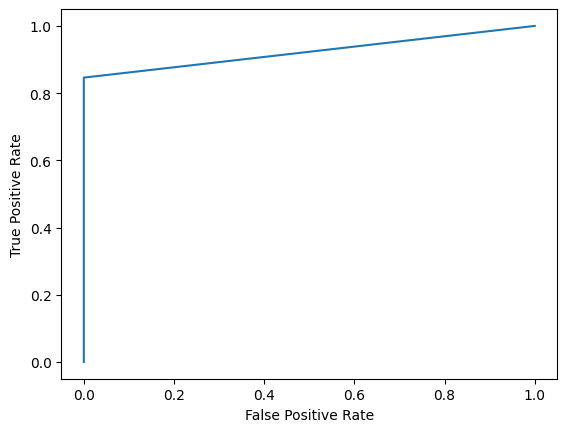

In [34]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

In [35]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.917
Precision:1.000
Recall:  0.846
F1-score: 0.917
ROC-AUC:0.993

Confusion Matrix:
 [[11  0]
 [ 2 11]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      1.00      0.92        11
         1.0       1.00      0.85      0.92        13

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24



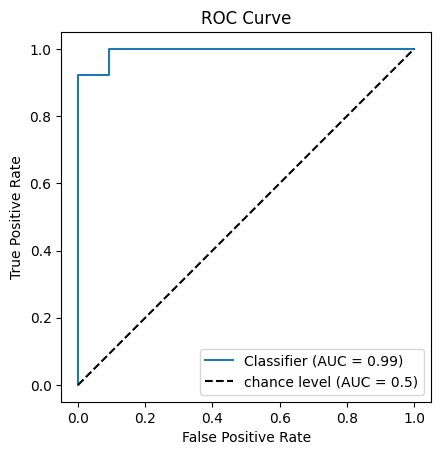

In [36]:
RocCurveDisplay.from_predictions(y_test, y_proba)

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

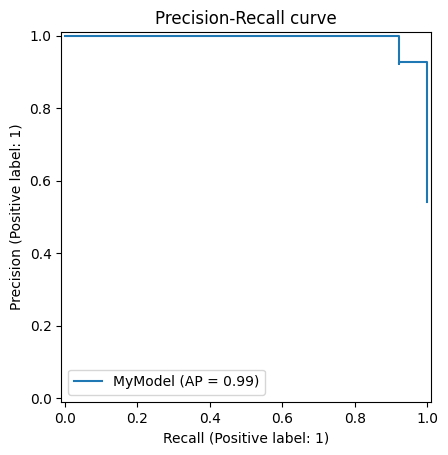

In [37]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()